In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt

import h5py
import pandas as pd

from omegaconf import DictConfig, OmegaConf

from faith.preprocess.pipelines import processing_v0
from faith.preprocess.util.utils import index_dataset
from faith.train.data.datasets.file_based import JoblibDataset
from faith.train.data import get_file_paths

In [50]:
cfg_path = "config/egebench.yaml"
cfg = OmegaConf.load(cfg_path)
cfg = OmegaConf.to_container(cfg)

In [51]:
out_dir = '../data/egebench'
out_dir = Path(out_dir)
out_dir.mkdir(parents=True,exist_ok=True)

In [52]:
tm_labels_path = '/projects/EKOLEMEN/survival_tm/tm_labels.h5'
tm_labels_path = Path(tm_labels_path)
with h5py.File(tm_labels_path, 'r') as f:
    tm_shots = list(f.keys())
tm_shots = [int(shot) for shot in tm_shots]
tm_shots.sort()

In [53]:
index = tm_shots.index(183225)
print(index)

13984


In [36]:
selected_tm_shots = [
    9640, # magnetic mode
    9641,
    10018,
    12953,
    13984, # microtearing mode
    14870,
    14828,
    16555,
]

In [89]:
for shot in selected_tm_shots:
    print(tm_shots[shot])

170000
170001
170669
178631
183225
186472
186292
190736


In [ ]:
for shot in selected_tm_shots:
    processing_v0.pipeline(tm_shots[shot], cfg, out_dir, False)

In [56]:
index_dataset(out_dir)

In [57]:
file_paths = get_file_paths('egebench', out_dir.parent)
file_paths.sort()

In [65]:
dataset = JoblibDataset(
    file_paths=file_paths,
    subseq_len=100000,
    input_key=['co2','mhr','ece','bes'],
    auto_detect_keys=False,
)
dataset.worker_init()
print(len(dataset))

184


In [138]:
file_paths[0].split('/')[-1].split('_')[0]

'170000'

In [66]:
from scipy.signal import ShortTimeFFT, windows
import torch

In [67]:
fs = 500
hop = 128
win = windows.hann(2048)
SFT = ShortTimeFFT(win, hop, fs)

In [73]:
dataset[0][0]['co2'].shape

torch.Size([4, 1, 100000])

In [187]:
diag_channels = {
    'mhr': 3,
    'ece': 12,
    'bes': 30,
    'co2': 0,
}

In [188]:
a,b,c = dataset.subseq_index[idx]
print(a)
print(b / 500000)
print(c / 500000)

4
3.4
3.6


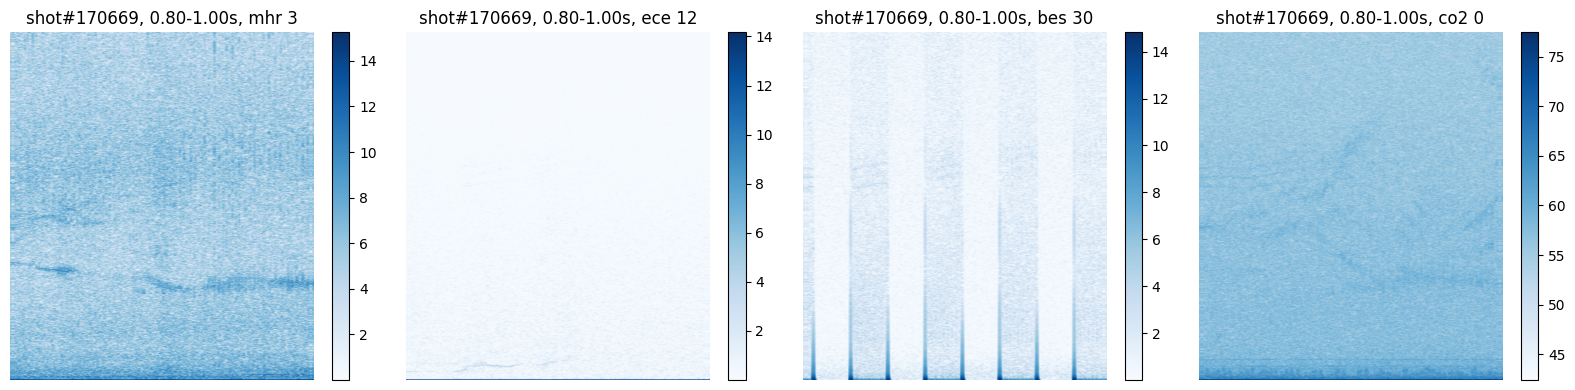

In [241]:
idx = 65


shotidx, t0_raw, t1_raw = dataset.subseq_index[idx]
shotn = file_paths[shotidx].split('/')[-1].split('_')[0]
t0 = t0_raw / 500000
t1 = t1_raw / 500000

fig, axs = plt.subplots(
    nrows=1,
    ncols=len(diag_channels),
    figsize=(len(diag_channels)*4, 4)
)
for i, (diagnostic, channel) in enumerate(diag_channels.items()):
    data = dataset[idx][0][diagnostic][channel][0].numpy().flatten()
    Sxx = SFT.spectrogram(x=data, padding='even')
    Sxx = np.log1p(Sxx)
    img = axs[i].imshow(
        Sxx,
        aspect='auto',
        cmap='Blues',
        origin='lower',
    )
    axs[i].axis('off')
    plt.colorbar(img, ax=axs[i])
    axs[i].set_title(f'shot#{shotn}, {t0:.2f}-{t1:.2f}s, {diagnostic} {channel}')
plt.tight_layout()
plt.show()

In [248]:
Sxx = Sxx[20:]

In [249]:
from skimage.filters import (
    threshold_otsu, 
    threshold_li, 
    threshold_yen, 
    threshold_triangle,
    threshold_mean,
    threshold_minimum,
    threshold_isodata
)

# Apply various thresholding methods to find optimal thresholds
thresholds = {}
thresholds['Otsu'] = threshold_otsu(Sxx)
thresholds['Li'] = threshold_li(Sxx)
thresholds['Yen'] = threshold_yen(Sxx)
thresholds['Triangle'] = threshold_triangle(Sxx)
thresholds['Mean'] = threshold_mean(Sxx)
thresholds['Minimum'] = threshold_minimum(Sxx)
thresholds['Isodata'] = threshold_isodata(Sxx)
thresholds['90th Quantile'] = np.quantile(Sxx, 0.90)

print("Threshold comparison:")
for method, thresh_val in thresholds.items():
    print(f"{method}: {thresh_val:.4f}")


Threshold comparison:
Otsu: 56.5096
Li: 56.3911
Yen: 60.2057
Triangle: 52.7254
Mean: 56.6220
Minimum: 43.5731
Isodata: 56.4216
90th Quantile: 58.6030


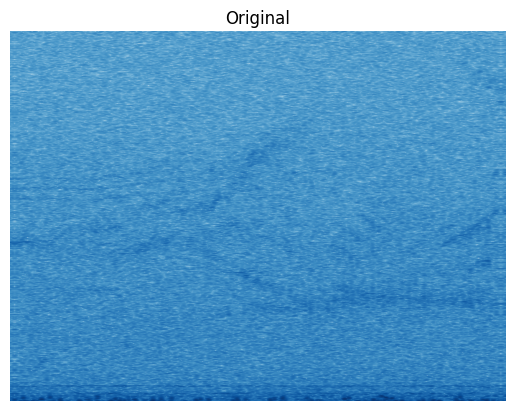

In [250]:
plt.imshow(
    Sxx,
    aspect='auto',
    cmap='Blues',
    origin='lower',
)
plt.title(f'Original')
plt.axis('off')
plt.show()

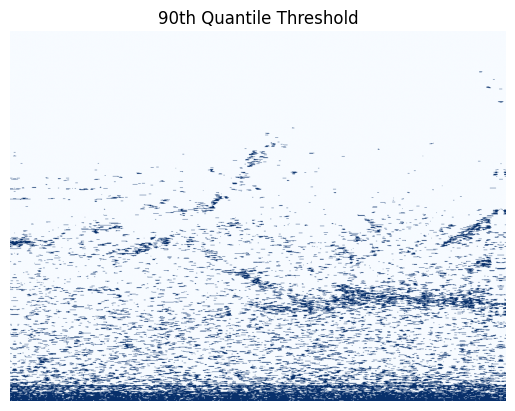

In [256]:
method = '90th Quantile'
plt.imshow(
    Sxx > thresholds[method],
    aspect='auto',
    cmap='Blues',
    origin='lower',
)
plt.title(f'{method} Threshold')
plt.axis('off')
plt.show()